In [1]:
# Imports
# Importo las Bibliotecas que voy a usar en el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# DataSources
df = pd.read_csv("data/delitos_2024.csv")

In [3]:
# Functions
# Definición de las funciones quevoy a usar en el proyecto.

def mostrar_valores_unicos(df, columnas):
    """
    Imprime en pantalla los valores únicos y sus frecuencias para 
    cada columna en 'columnas'
    """
    for col in columnas:
        print(f"\n{'='*50}")
        print(f"Columna: {col}")
        print(f"{'='*50}")

        conteo = df[col].value_counts(dropna=False)
        i=1
        for valor, cantidad in conteo.items():
            print(f"{[i]}\t{repr(valor)} -> {cantidad}")
            i+=1

def valores_unicos_a_df(df, columna):
    """
    Devuelve un DataFrame con los valores únicos y su frecuencia
    para una columna específica.
    """

    # reviso qe exista la columna, en caso de que me equivoque al escribirel nombre.
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame")

    resultado = (
        df[columna]
        .value_counts(dropna=False)
        .reset_index()
    )
    resultado.columns = ['valor', 'cantidad']
    return resultado

# Exploración de datos (DEA)
Luego de haber cargado el dataset, hago una inspección geneal del dataframe buscando validar que sea útil para el TP.
```
Ejemplos
- df.head(), df.info(), df.describe()
- Detección de valores nulos (df.isnull().sum())
```

## Inspección rápida

In [4]:
df.shape # El DataFrame tiene que tener al menos 50K registros y 10 columnaspara este TP

(158838, 15)

In [5]:
# veo la estructura del DataFrame.
# con el datatype puedo completar el diccionario de datos que pide el TP
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   158838 non-null  int64  
 1   anio      158838 non-null  int64  
 2   mes       158838 non-null  str    
 3   dia       158838 non-null  str    
 4   fecha     158838 non-null  str    
 5   franja    158791 non-null  float64
 6   tipo      158838 non-null  str    
 7   subtipo   158838 non-null  str    
 8   uso_arma  158838 non-null  str    
 9   uso_moto  158838 non-null  str    
 10  barrio    154916 non-null  str    
 11  comuna    154916 non-null  float64
 12  latitud   155004 non-null  float64
 13  longitud  155004 non-null  float64
 14  cantidad  158838 non-null  int64  
dtypes: float64(4), int64(3), str(8)
memory usage: 18.2 MB
None


In [6]:
df.head() # Sin argumentos, el método head() me trae los primeros 5 elementos del DataFrame

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,1399612,2024,ENERO,LUNES,2024-01-01,17.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.585182,-58.453967,1
1,1399613,2024,ENERO,LUNES,2024-01-01,6.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.584186,-58.453476,1
2,1399614,2024,ENERO,LUNES,2024-01-01,1.0,Hurto,Hurto total,NO,NO,MATADEROS,9.0,-34.664360,-58.502121,1
3,1399615,2024,ENERO,LUNES,2024-01-01,19.0,Robo,Robo total,NO,NO,PALERMO,14.0,-34.564851,-58.434855,1
4,1399616,2024,ENERO,LUNES,2024-01-01,20.0,Hurto,Hurto total,NO,NO,SAN NICOLAS,1.0,-34.605522,-58.391176,1


In [7]:
# Obtengo una muestra al azar del DataFrame
df.sample(n=3)

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
77095,1476707,2024,JULIO,SABADO,2024-07-27,13.0,Hurto,Hurto total,NO,NO,PALERMO,14.0,-34.575167,-58.435158,1
56179,1455791,2024,MAYO,MIERCOLES,2024-05-29,23.0,Robo,Robo total,NO,NO,PALERMO,14.0,-34.573982,-58.436912,1
28966,1428578,2024,MARZO,SABADO,2024-03-16,22.0,Robo,Robo total,SI,NO,FLORESTA,10.0,-34.630946,-58.480405,1


In [8]:
df.tail() # Sin argumentos, el método tail() me trae los últimos 5 elementos del DataFrame

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
158833,1591956,2024,DICIEMBRE,JUEVES,2024-12-12,0.0,Homicidios,Homicidios dolosos,NO,NO,RECOLETA,2.0,-34.595580,-58.408997,1
158834,1591957,2024,DICIEMBRE,DOMINGO,2024-12-15,1.0,Homicidios,Homicidios dolosos,NO,NO,NUEVA POMPEYA,4.0,-34.650123,-58.405448,1
158835,1591958,2024,DICIEMBRE,DOMINGO,2024-12-15,5.0,Homicidios,Homicidios dolosos,NO,NO,CONSTITUCION,1.0,-34.619920,-58.388807,1
158836,1591959,2024,DICIEMBRE,MIERCOLES,2024-12-18,5.0,Homicidios,Homicidios dolosos,NO,NO,BARRACAS,4.0,-34.655290,-58.398290,1
158837,1591960,2024,DICIEMBRE,DOMINGO,2024-12-29,21.0,Homicidios,Homicidios dolosos,NO,NO,PARQUE AVELLANEDA,9.0,-34.646104,-58.469811,1


In [9]:
# Uso 'describe' par ver si, a simple vista, hay algún valor que me llame la atención
# > Datos de latitud/longitud, interesante para un mapa
# > Sólo hay datos de 2024 (min == max == 2024)
df.describe()

,id-mapa,anio,franja,comuna,latitud,longitud,cantidad
count,1.588380e+05,158838.0,158791.000000,154916.000000,1.550040e+05,1.550040e+05,158838.0
mean,1.481333e+06,2024.0,13.056294,7.447591,-1.116540e+13,-3.775561e+12,1.0
std,5.011975e+04,0.0,6.376709,4.601954,1.965873e+15,1.486459e+15,0.0
min,1.399612e+06,2024.0,0.000000,1.000000,-3.464208e+17,-5.852271e+17,1.0
25%,1.439321e+06,2024.0,8.000000,3.000000,-3.463380e+01,-5.846882e+01,1.0
50%,1.479030e+06,2024.0,14.000000,7.000000,-3.461158e+01,-5.843487e+01,1.0
75%,1.518740e+06,2024.0,18.000000,12.000000,-3.459247e+01,-5.840112e+01,1.0
max,1.591960e+06,2024.0,23.000000,15.000000,0.000000e+00,0.000000e+00,1.0


In [10]:
# hay elementos duplicados?
df.duplicated().sum()

np.int64(0)

In [11]:
# recuento de valores únicos que tiene cada columna
df.nunique()

id-mapa     158838
anio             1
mes             12
dia              7
fecha          366
franja          24
tipo             6
subtipo          9
uso_arma         2
uso_moto         2
barrio          48
comuna          15
latitud      92284
longitud     94761
cantidad         1
dtype: int64

## Análisis de columnas y valores

### Columnas de fechas

```text
#   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 1   anio      158838 non-null  int64  
 2   mes       158838 non-null  str    
 3   dia       158838 non-null  str    
 4   fecha     158838 non-null  str    
```

In [12]:
df['anio'].unique()

array([2024])

In [13]:
df['mes'].unique()

<StringArray>
[     'ENERO',    'FEBRERO',      'MARZO',      'ABRIL',       'MAYO',
      'JUNIO',      'JULIO',     'AGOSTO', 'SEPTIEMBRE',    'OCTUBRE',
  'NOVIEMBRE',  'DICIEMBRE']
Length: 12, dtype: str

In [14]:
# Acá hay un problema, si son strings, 'ABRIL' está antes que 'ENERO'.
# Debería ser una variable categórica
# Así como está, puede traerme problemas para para analizar/graficar.

In [15]:
df['dia'].unique()

<StringArray>
['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']
Length: 7, dtype: str

In [16]:
# Con 'dia' tengo el mismo problema que con 'mes': 'JUEVES' está antes que 'LUNES'
# Debería ser una variable categórica
# Así como está, puede traerme problemas para para analizar/graficar.

In [17]:
df['fecha'].unique()
# trae 366 porque 2024 fue año bisiesto

<StringArray>
['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
 '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10',
 ...
 '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26',
 '2024-12-27', '2024-12-28', '2024-12-29', '2024-12-30', '2024-12-31']
Length: 366, dtype: str

In [18]:
# Me conviene convertir la fecha de String a Date
df['fecha'] = pd.to_datetime(df['fecha'])

In [19]:
max = df['fecha'].max()
print ("\nValores minimos y máximos:")
print (f"fecha_min: {df['fecha'].min()}")
print (f"fecha_max: {df['fecha'].max()}")
print ("\nPrimer y último (index) valor del dataframe:")
print (f"index 0: {df['fecha'].iloc[0]}")
print (f"index N: {df['fecha'].iloc[-1]}")


Valores minimos y máximos:
fecha_min: 2024-01-01 00:00:00
fecha_max: 2024-12-31 00:00:00

Primer y último (index) valor del dataframe:
index 0: 2024-01-01 00:00:00
index N: 2024-12-29 00:00:00


In [20]:
# el dataframe no está ordenado por fecha

In [21]:
# 'dia' y 'mes' están como string, pero los puedo calcular en base a 'fecha' para que haya consistencia
# Eso locale=es_AR para representación en español
df['mes'] = df['fecha'].dt.month_name(locale='es_AR')
df['dia'] = df['fecha'].dt.day_name(locale='es_AR')

In [22]:
mostrar_valores_unicos(df,['mes'])


Columna: mes
[1]	'Marzo' -> 13915
[2]	'Noviembre' -> 13645
[3]	'Enero' -> 13626
[4]	'Febrero' -> 13592
[5]	'Abril' -> 13518
[6]	'Mayo' -> 13383
[7]	'Diciembre' -> 13361
[8]	'Julio' -> 12968
[9]	'Octubre' -> 12941
[10]	'Junio' -> 12874
[11]	'Agosto' -> 12708
[12]	'Septiembre' -> 12307


In [23]:
a= valores_unicos_a_df(df, 'mes') # uso mi funcion
a.sort_values('valor', ascending=True)

,valor,cantidad
4,Abril,13518
10,Agosto,12708
6,Diciembre,13361
2,Enero,13626
3,Febrero,13592
7,Julio,12968
9,Junio,12874
0,Marzo,13915
5,Mayo,13383
1,Noviembre,13645


In [24]:
# bastante parejos los números mensuales

In [25]:
mostrar_valores_unicos(df,['dia'])


Columna: dia
[1]	'Viernes' -> 24216
[2]	'Lunes' -> 23229
[3]	'Miércoles' -> 23038
[4]	'Sábado' -> 22943
[5]	'Jueves' -> 22921
[6]	'Martes' -> 22501
[7]	'Domingo' -> 19990


In [26]:
# los domingos bajan los delitos?

In [27]:
# pero esta conversión tiene el problema de que 'dia' y 'mes' no se convierten en categóricas
#
# Pandas tiene una forma de convertir estas variables categóricas
#  Ref: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Categorical.html
#  Ref: https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html
#
# El uso de este tipo de datos optimiza el DataFrame

In [28]:
# Conversión de los meses a variable categórica (aunque se almacene como string)
# no puedo hacer esto directamente 
#
#    df['mes'] = df['mes'].astype('category')
#
# porque la relación entre los meses SI ES CATEGORICA (dociembre > noviembre)

df['mes'] = pd.Categorical(
    df['mes'],
    categories=[
        'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
        'Julio', 'Agosto','Septiembre','Octubre','Noviembre', 'Diciembre'
    ],
    ordered=True
)
df['mes'] # me lo tiene ue mostrar como dtype:category

0             Enero
1             Enero
2             Enero
3             Enero
4             Enero
            ...    
158833    Diciembre
158834    Diciembre
158835    Diciembre
158836    Diciembre
158837    Diciembre
Name: mes, Length: 158838, dtype: category
Categories (12, str): ['Enero' < 'Febrero' < 'Marzo' < 'Abril' ... 'Septiembre' < 'Octubre' < 'Noviembre' < 'Diciembre']

In [29]:
# Hago lo mismo, pero para los días
#
# Acá, tomo la decisión que le primer día de la semana será el LUNES
#    lunes < domingo

df['dia'] = pd.Categorical(
    df['dia'],
    categories=['Lunes', 'Martes', 'Miércoles', 'Jueves','Viernes','Sábado','Domingo'],
    ordered=True
)
df['dia'] # me lo tiene ue mostrar como dtype:category

0             Lunes
1             Lunes
2             Lunes
3             Lunes
4             Lunes
            ...    
158833       Jueves
158834      Domingo
158835      Domingo
158836    Miércoles
158837      Domingo
Name: dia, Length: 158838, dtype: category
Categories (7, str): ['Lunes' < 'Martes' < 'Miércoles' < 'Jueves' < 'Viernes' < 'Sábado' < 'Domingo']

In [30]:
df.sample(n=3)

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
140815,1541628,2024,Enero,Jueves,2024-01-11,14.0,Amenazas,Amenazas,NO,NO,FLORES,7.0,-34.650662,-58.443362,1
96890,1496502,2024,Septiembre,Martes,2024-09-24,13.0,Robo,Robo total,SI,NO,BARRACAS,4.0,-34.642920,-58.389671,1
110274,1509886,2024,Noviembre,Sábado,2024-11-02,2.0,Robo,Robo total,SI,NO,CONSTITUCION,1.0,-34.628997,-58.381397,1


### Datos String

In [31]:
columnas = [
    'tipo', 'subtipo','uso_arma','uso_moto'
]

mostrar_valores_unicos(df,columnas)


Columna: tipo
[1]	'Robo' -> 68392
[2]	'Hurto' -> 62771
[3]	'Vialidad' -> 10574
[4]	'Lesiones' -> 9420
[5]	'Amenazas' -> 7603
[6]	'Homicidios' -> 78

Columna: subtipo
[1]	'Robo total' -> 67252
[2]	'Hurto total' -> 58119
[3]	'Lesiones por siniestros viales' -> 10464
[4]	'Lesiones Dolosas' -> 9420
[5]	'Amenazas' -> 7603
[6]	'Hurto automotor' -> 4652
[7]	'Robo automotor' -> 1140
[8]	'Muertes por siniestros viales' -> 110
[9]	'Homicidios dolosos' -> 78

Columna: uso_arma
[1]	'NO' -> 150393
[2]	'SI' -> 8445

Columna: uso_moto
[1]	'NO' -> 153080
[2]	'SI' -> 5758


In [32]:
#tipo_delito

In [33]:
# 'uso_arma' y 'uso_moto' son "SI/NO" -> las puedo convertir a boolean
df['uso_arma'] = df['uso_arma'].eq('SI')
df['uso_moto'] = df['uso_moto'].eq('SI')

> Las variables `'uso_arma'` y `'uso_moto'` fueron transformadas a tipo booleano debido a que representan variables binarias dicotómicas (SI/NO), facilitando el análisis estadístico y el cálculo de proporciones.

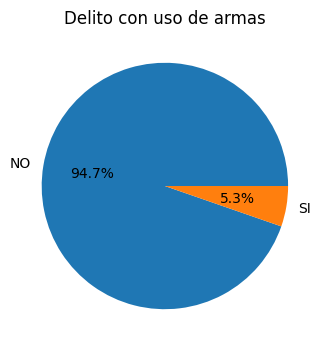

In [34]:
uso_arma = (
    df['uso_arma']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    uso_arma.values,
    labels=['NO', 'SI'],
    autopct='%1.1f%%',
)

plt.title('Delito con uso de armas')
plt.show()

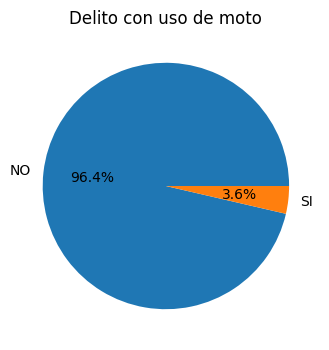

In [35]:
uso_moto = (
    df['uso_moto']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    uso_moto.values,
    labels=['NO', 'SI'],
    autopct='%1.1f%%',
)

plt.title('Delito con uso de moto')
plt.show()

In [36]:
# 'tipo' y 'subtipo' son categorías bien definidas, no parecen campos de texto libre.
# 'tipo' 6 valores distintos
# 'subtipo' 9 valores distintos
# tengho ~159K registros.

df['tipo'] = df['tipo'].astype('category')
df['subtipo'] = df['subtipo'].astype('category')

In [37]:
df['barrio'].describe()

count      154916
unique         48
top       PALERMO
freq        12794
Name: barrio, dtype: object

In [38]:
mostrar_valores_unicos(df,['barrio','comuna'])


Columna: barrio
[1]	'PALERMO' -> 12794
[2]	'BALVANERA' -> 9967
[3]	'FLORES' -> 8509
[4]	'CABALLITO' -> 6863
[5]	'RECOLETA' -> 6690
[6]	'ALMAGRO' -> 6026
[7]	'VILLA LUGANO' -> 5861
[8]	'SAN NICOLAS' -> 5831
[9]	'BARRACAS' -> 5389
[10]	'BELGRANO' -> 5043
[11]	'VILLA CRESPO' -> 4686
[12]	'CONSTITUCION' -> 4047
[13]	'MONSERRAT' -> 3997
[14]	'PARQUE CHACABUCO' -> 3987
[15]	'RETIRO' -> 3984
[16]	nan -> 3922
[17]	'NUEVA POMPEYA' -> 3657
[18]	'MATADEROS' -> 3366
[19]	'VILLA SOLDATI' -> 3352
[20]	'VILLA URQUIZA' -> 3173
[21]	'VILLA DEVOTO' -> 3060
[22]	'LINIERS' -> 2963
[23]	'BOCA' -> 2747
[24]	'SAN CRISTOBAL' -> 2565
[25]	'PARQUE PATRICIOS' -> 2446
[26]	'SAAVEDRA' -> 2406
[27]	'CHACARITA' -> 2221
[28]	'SAN TELMO' -> 2211
[29]	'PARQUE AVELLANEDA' -> 2099
[30]	'NUÑEZ' -> 2096
[31]	'COLEGIALES' -> 2036
[32]	'BOEDO' -> 2003
[33]	'FLORESTA' -> 1878
[34]	'VILLA DEL PARQUE' -> 1830
[35]	'VILLA PUEYRREDON' -> 1598
[36]	'VILLA GRAL. MITRE' -> 1452
[37]	'VILLA LURO' -> 1437
[38]	'VELEZ SARSFIELD' -> 13

#### OJO: posibilidad de data para analizar/graficar
```
- [1]	'PALERMO' -> 12794
- [2]	'BALVANERA' -> 9967
- [3]	'FLORES' -> 8509
- [4]	'CABALLITO' -> 6863
```
##### Qué pasa con esos barrios?
>- concentración del delito
>- desigualdad territorial
>- diferencias entre comunas
>- agrupar por barrios por comunas

In [39]:
#tengo
## Barrios
# - ~159k registros
# - ~49 valores únicos de barrio
# - mucha repetición.

# en base a documentación de pandas, conviene convertirlo a categórica
df['barrio'] = df['barrio'].astype('category')

In [40]:
## Comunas
# las comunas en CABA se identifican con un número entero en el rango 1-15.
# no tiene sentido almacenarlo como float, ya que en la práctica es una variable categórica/discreta (no es contínua)
df['comuna'] = df['comuna'].astype('Int64')

In [41]:
## franja
# franja está como float, pero sólo tiene valores enteros 0-23
# franja representa la hora del delito
# al igual que comunas, lo convierto a entero (con nulos)
a= valores_unicos_a_df(df, 'franja') # uso mi funcion
a.sort_values('valor', ascending=True)

df['franja'] = df['franja'].astype('Int64')
a= valores_unicos_a_df(df, 'franja') # uso mi funcion
a.sort_values('valor', ascending=True)

,valor,cantidad
17,0,5119
20,1,3604
22,2,3002
23,3,2947
21,4,3014
19,5,3633
18,6,5043
8,7,7785
4,8,8210
11,9,7527


#### 'id-mapa'

- Esta columna es de tipo float
- En la descripción del dataset se menciona que es un indicador único

In [42]:
df['id-mapa'].count()

np.int64(158838)

In [43]:
df['id-mapa'].nunique()

158838

In [44]:
df.shape

(158838, 15)

In [45]:
# > 'id-mapa' tiene la misma cantidad de elementos únicos que la cantidad de registros
# > esto parece una PK autoincremental.
# > tomo la decisión de elimninar esa columna del análisis
df.pop('id-mapa')

0         1399612
1         1399613
2         1399614
3         1399615
4         1399616
           ...   
158833    1591956
158834    1591957
158835    1591958
158836    1591959
158837    1591960
Name: id-mapa, Length: 158838, dtype: int64

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   anio      158838 non-null  int64         
 1   mes       158838 non-null  category      
 2   dia       158838 non-null  category      
 3   fecha     158838 non-null  datetime64[us]
 4   franja    158791 non-null  Int64         
 5   tipo      158838 non-null  category      
 6   subtipo   158838 non-null  category      
 7   uso_arma  158838 non-null  bool          
 8   uso_moto  158838 non-null  bool          
 9   barrio    154916 non-null  category      
 10  comuna    154916 non-null  Int64         
 11  latitud   155004 non-null  float64       
 12  longitud  155004 non-null  float64       
 13  cantidad  158838 non-null  int64         
dtypes: Int64(2), bool(2), category(5), datetime64[us](1), float64(2), int64(2)
memory usage: 9.8 MB


## Como conclusión del tratamiento de los datos del dataset:
- Se trataron los campos relacionados a fecha, convirtiéndolos en tipo fecha o categóricos.
- Los campos string se transformaron en categóricos o boolean según el tipo de dato que representan.
- El campo float que almacena un número asociado a una comuna (1-15) se convirtió a entero.
  
Con estas optimizaciones, el dataframe pasó de:
```
memory usage: 18.2 MB  ->  memory usage: 9.8 MB
```


El dataset consume ahora menos recursos

Habiendo trabajado los datos, se procede a plantear preguntas sobre los datos y tratar de responderlas con gráficos

# Análisis / gráficos

**Observaciones para el tratamiento de gráficos.**

- Cada registro (fila) del DataSet corresponde a un único delito.

In [87]:
# config globales para mis gráficos
sns.set_theme(style="whitegrid")

## Evolución de reporte de delitos por día

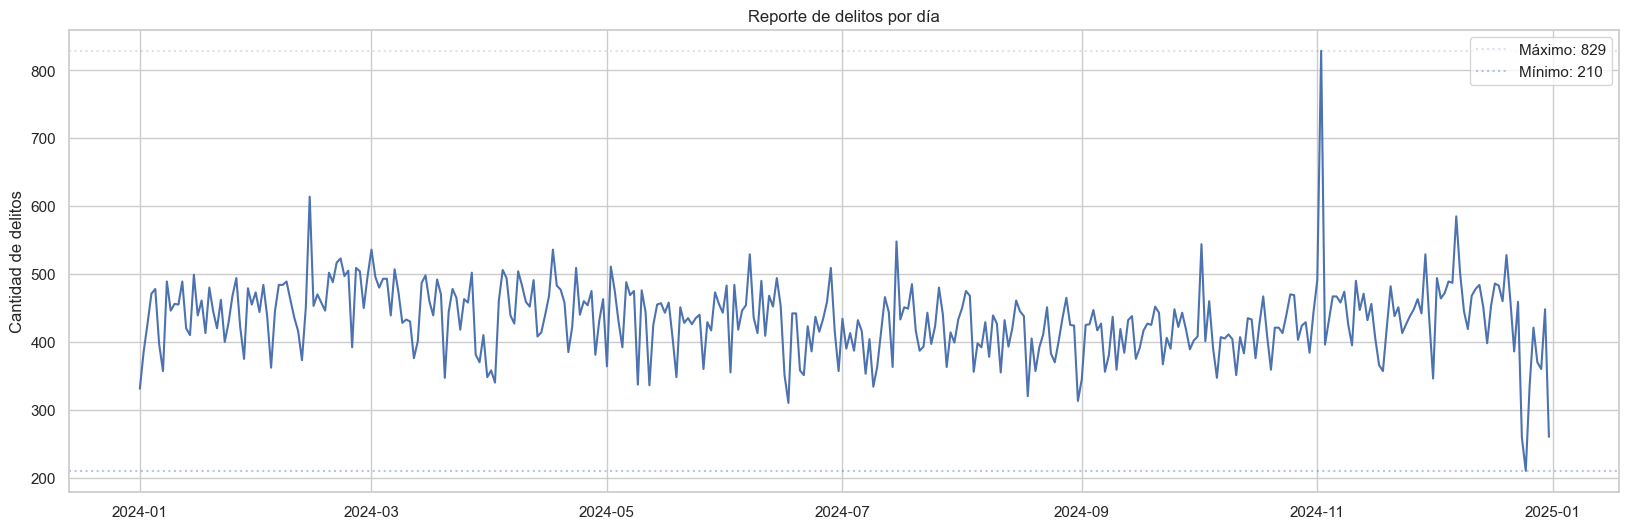

In [129]:
# Delitos por fecha
delitos_fecha = (
    df.groupby('fecha')['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(20, 6))

sns.lineplot(
    data=delitos_fecha,
    x='fecha',
    y='cantidad'
)

# Buscar máximo y mínimo
maximo = delitos_fecha['cantidad'].max()
minimo = delitos_fecha['cantidad'].min()

# Dibujar líneas horizontales
plt.axhline(
    y=maximo,
    linestyle='dotted',
    label=f'Máximo: {maximo}',
    alpha=0.2
)

plt.axhline(
    y=minimo,
    linestyle='dotted',
    label=f'Mínimo: {minimo}',
    alpha=0.4
)

plt.legend()

plt.title('Reporte de delitos por día')
plt.xlabel('')
plt.ylabel('Cantidad de delitos')

plt.show()

## Reporte de delitos por día y tipo de delito

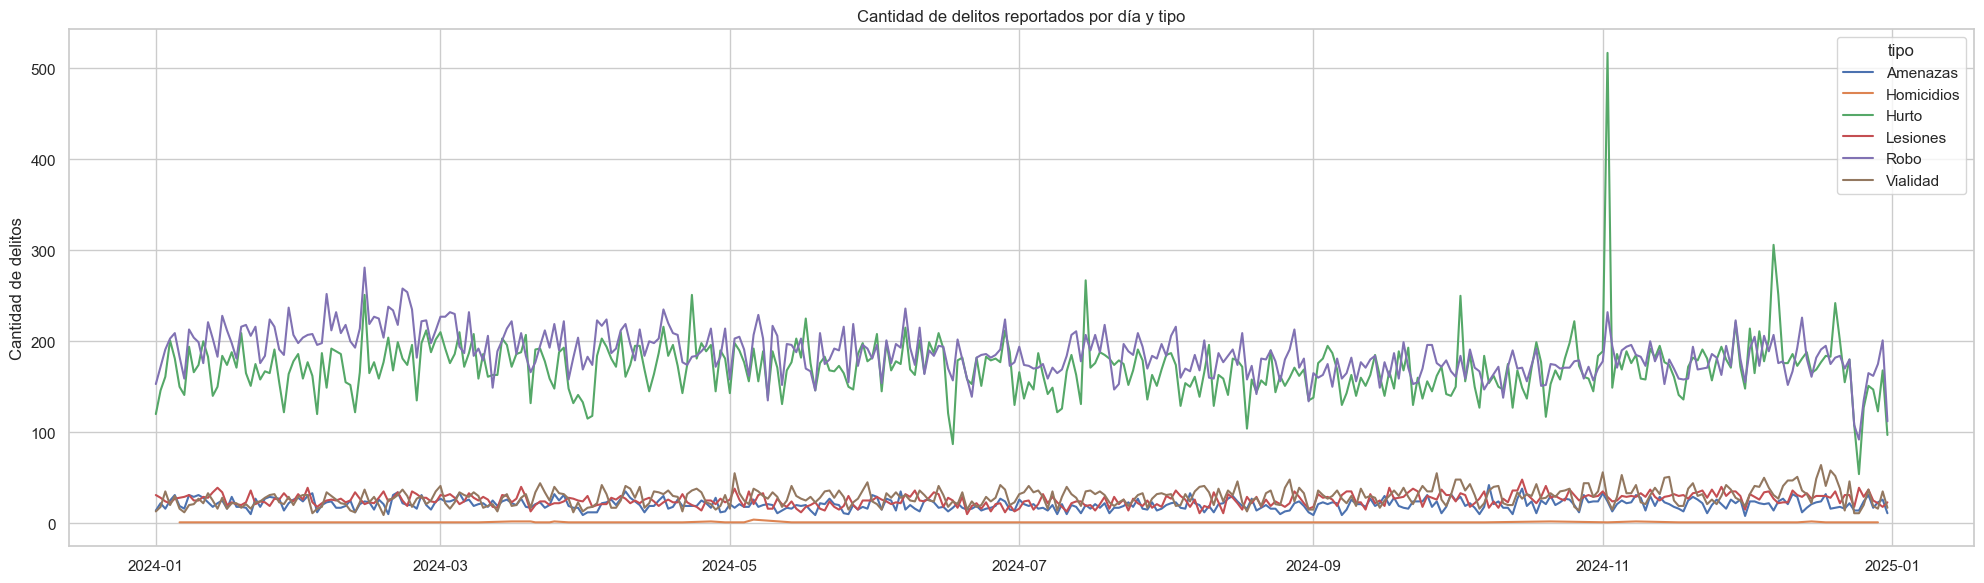

In [126]:
# Agrupar por fecha y tipo de delito
delitos_fecha_tipo = (
    df.groupby(['fecha', 'tipo'], observed=True)['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(20, 6))

sns.lineplot(
    data=delitos_fecha_tipo,
    x='fecha',
    y='cantidad',
    hue='tipo',
    #palette='Accent'
)

# Títulos y etiquetas
plt.title('Cantidad de delitos reportados por día y tipo')
plt.xlabel('')
plt.ylabel('Cantidad de delitos')

plt.tight_layout()
plt.show()

In [97]:
sns.color_palette('flare')

[(0.9155979, 0.55210684, 0.42070204),
 (0.888292, 0.40830288, 0.36223756),
 (0.81942908, 0.28911553, 0.38102921),
 (0.69226314, 0.23413578, 0.42480327),
 (0.56041794, 0.19845221, 0.44207535),
 (0.42355299, 0.16934709, 0.42581586)]

## Delitos por hora del día

### Hay momentos del día que concentre más delitos que otros?

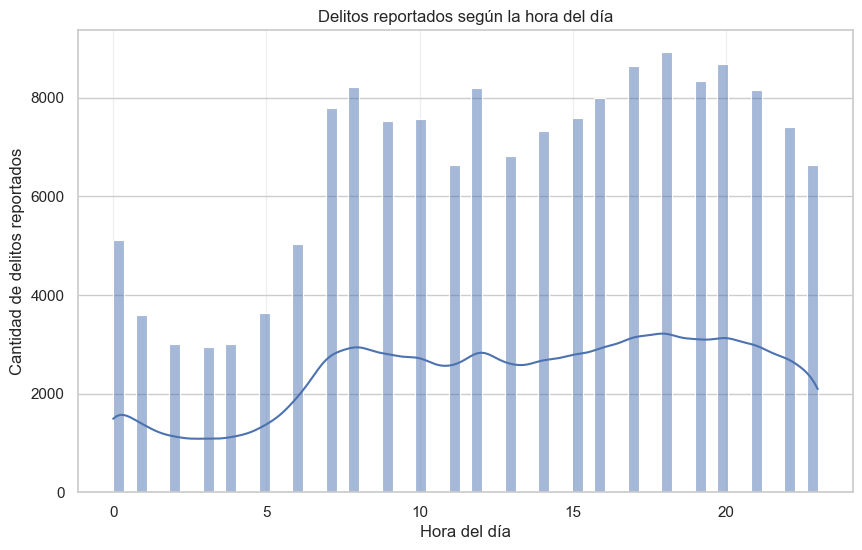

In [48]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=df, x='franja', kde=True) #en 'franja' está la hora

plt.title('Delitos reportados según la hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de delitos reportados')
plt.grid(axis='x', alpha=0.3)

plt.show()

### Análisis/conclusiones
- No se observa una distribución normal.
- El momento del día de **menor ocurrencia** de delitos se da por la madrugada, **de 1 a 5**.
- El momento del día de **mayor ocurrencia** de delitos se da pasada las **5 de la mañana**.

## Delitos por barrio

### Hay barrios que concentren más delitos que otros?

In [49]:
df['barrio'].nunique # Cantidad de barrios

<bound method IndexOpsMixin.nunique of 0                 CHACARITA
1                 CHACARITA
2                 MATADEROS
3                   PALERMO
4               SAN NICOLAS
                ...        
158833             RECOLETA
158834        NUEVA POMPEYA
158835         CONSTITUCION
158836             BARRACAS
158837    PARQUE AVELLANEDA
Name: barrio, Length: 158838, dtype: category
Categories (48, str): ['AGRONOMIA', 'ALMAGRO', 'BALVANERA', 'BARRACAS', ..., 'VILLA RIACHUELO', 'VILLA SANTA RITA', 'VILLA SOLDATI', 'VILLA URQUIZA']>

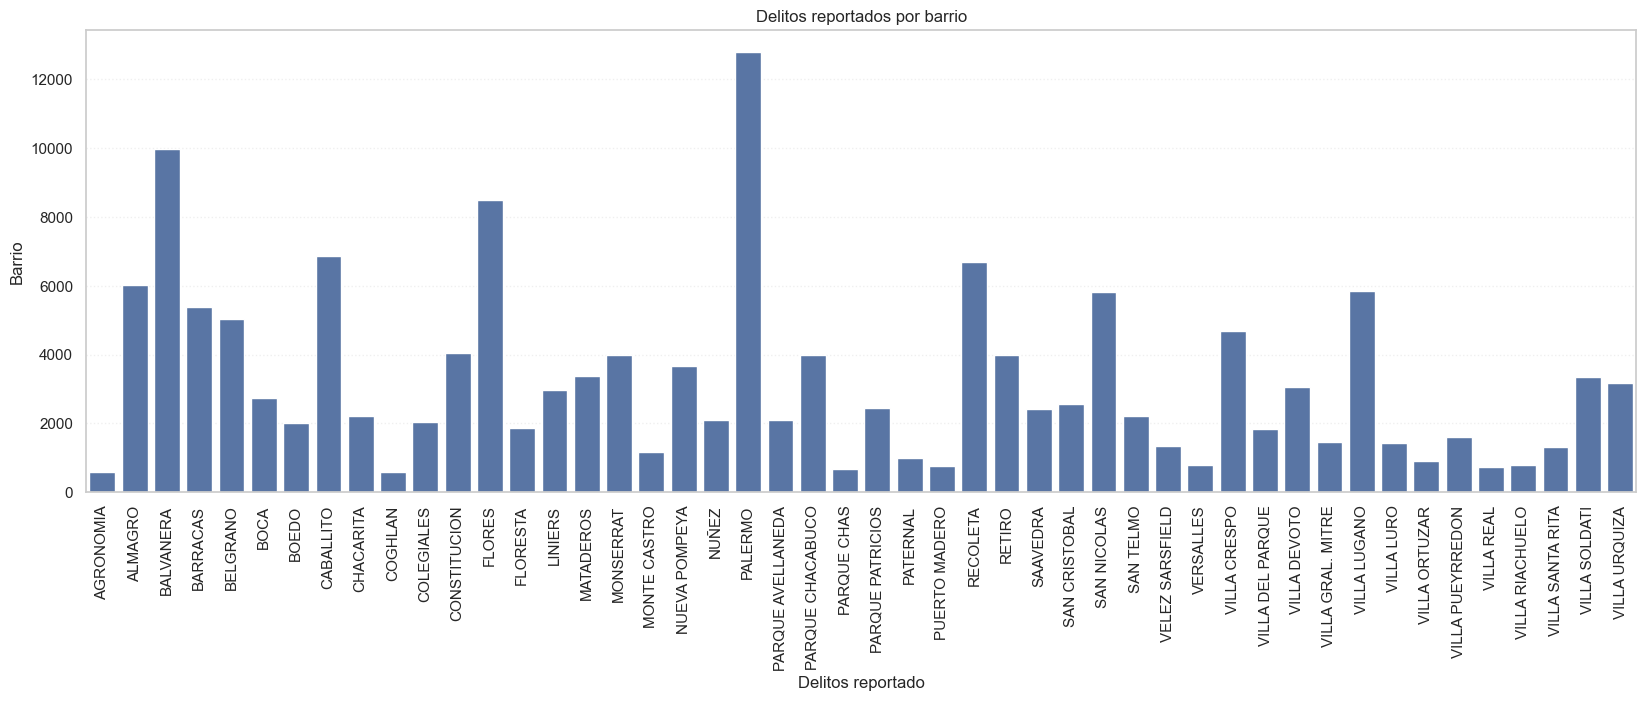

In [50]:
# Delitos por barrio
delitos_barrio = (
    df.groupby('barrio', observed=True)['cantidad']
    .sum()
    .reset_index() # esto me convierte el 'pandas.Series' a un 'pandas.DataFrame'
)
plt.figure(figsize=(20, 6))

sns.barplot(
    data=delitos_barrio,
    x='barrio',
    y='cantidad',
)
plt.title('Delitos reportados por barrio')
plt.xlabel('Delitos reportado')
plt.ylabel('Barrio')

plt.grid(axis='y',alpha=0.3, linestyle='dotted')
plt.xticks(rotation=90)


plt.show()

In [51]:
### puedo armar un Paretto 80/20?
total_delitos = delitos_barrio['cantidad'].sum()
total_barrios = len(delitos_barrio)

# ordeno 'delitos_barios' por 'cantidad' descendente
barrios = delitos_barrio.sort_values(
    by='cantidad',
    ascending=False
).reset_index(drop=True) # hago esto para tenerun datafreame

# delitos acumulados: creo la columna donde voy calculando el acumulado de delitos
barrios['cantidad_acumulada'] = barrios['cantidad'].cumsum()

# porcentaje individual: pordentaje de delitos de este barrio sobre el total
barrios['porcentaje'] = barrios['cantidad'] / total_delitos * 100

# porcentaje acumulado: porcentaje acumulado de cantidad de delitos
barrios['porcentaje_acumulado'] = barrios['porcentaje'].cumsum()

corte = 80 # a dónde quiero mi corte, en %

barrios_corte = barrios[barrios['porcentaje_acumulado'] <= corte]

barrios_p = len(barrios_corte)
porcentaje_barrios = barrios_p / total_barrios * 100

# Estadísitcas
print (f"Cantidad barrios: {total_barrios}")
print (f"Total de delitos: {total_delitos}")
print (f"Cantidad de barrios que acumulan {corte}% de los delitos: {barrios_p}")
print (f"Porcentaje de barrios que acumulan {corte}% de los delitos: {porcentaje_barrios:.2f}% ({barrios_p}/{total_barrios})")

Cantidad barrios: 48
Total de delitos: 154916
Cantidad de barrios que acumulan 80% de los delitos: 25
Porcentaje de barrios que acumulan 80% de los delitos: 52.08% (25/48)


In [52]:
barrios

,barrio,cantidad,cantidad_acumulada,porcentaje,porcentaje_acumulado
0,PALERMO,12794,12794,8.258669,8.258669
1,BALVANERA,9967,22761,6.433809,14.692479
2,FLORES,8509,31270,5.492654,20.185133
3,CABALLITO,6863,38133,4.430143,24.615275
4,RECOLETA,6690,44823,4.318469,28.933745
5,ALMAGRO,6026,50849,3.889850,32.823595
6,VILLA LUGANO,5861,56710,3.783341,36.606935
7,SAN NICOLAS,5831,62541,3.763975,40.370911
8,BARRACAS,5389,67930,3.478659,43.849570
9,BELGRANO,5043,72973,3.255313,47.104883


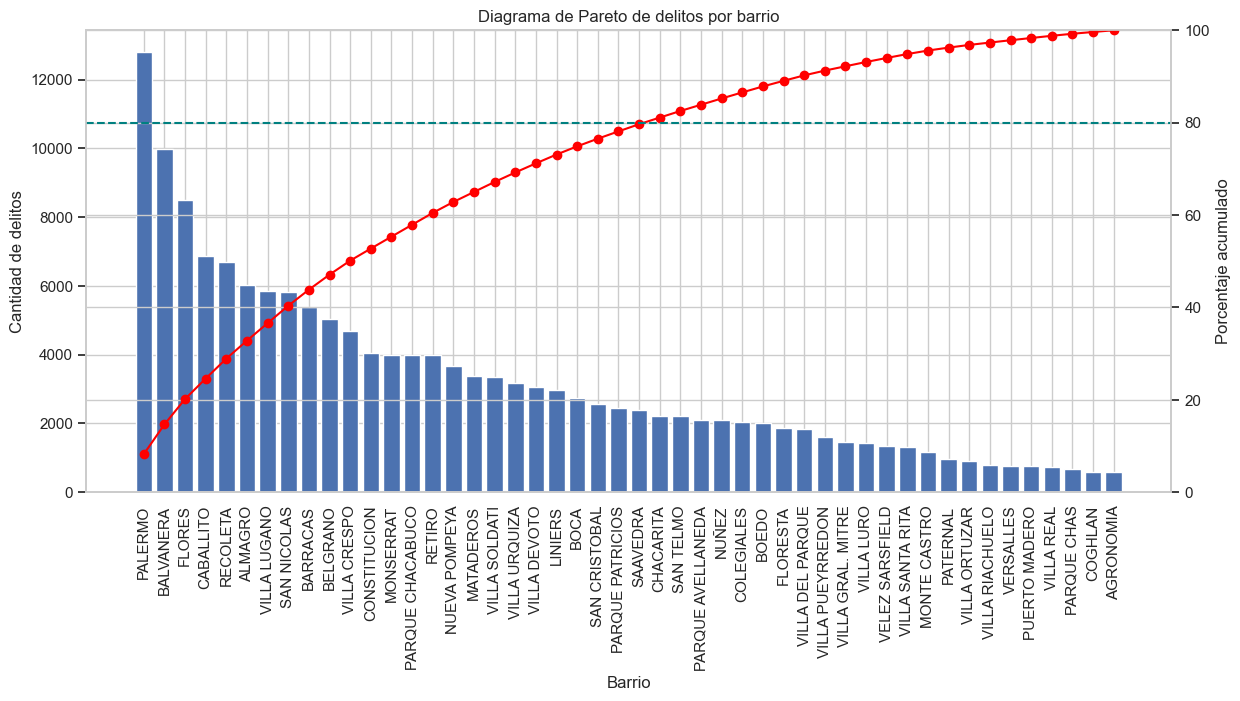

In [53]:
# parte 2, hago el gráfico

# tengo que armar subplots para meter más de 1 gráfico en eun lienzop
fig, ax1 = plt.subplots(figsize=(14,6))

# Barras (frecuencia)
ax1.bar(barrios['barrio'], barrios['cantidad'])

# Eje izquierdo
ax1.set_ylabel('Cantidad de delitos')
ax1.set_xlabel('Barrio')

# Rotar etiquetas poque se ven feas si están en horizntal
plt.xticks(rotation=90)

# eje derecho para porcentaje acumulado
ax2 = ax1.twinx()

# Línea acumulada
ax2.plot(
    barrios['barrio'],
    barrios['porcentaje_acumulado'],
    marker='o',
    color='red'
)

# Línea horizontal del 80%
ax2.axhline(80, linestyle='--', color='teal')

# Eje derecho
ax2.set_ylabel('Porcentaje acumulado')
ax2.set_ylim(0, 100)

#plt.grid(axis='y',alpha=0.3, linestyle='solid')
#plt.grid(axis='x',alpha=0.3, linestyle='solid')
plt.title('Diagrama de Pareto de delitos por barrio')

plt.show()

In [54]:
barrios['porcentaje'].sum()

np.float64(100.0)

               barrio  cantidad
0             PALERMO     12794
1           BALVANERA      9967
2              FLORES      8509
3           CABALLITO      6863
4            RECOLETA      6690
5             ALMAGRO      6026
6        VILLA LUGANO      5861
7         SAN NICOLAS      5831
8            BARRACAS      5389
9            BELGRANO      5043
10       VILLA CRESPO      4686
11       CONSTITUCION      4047
12          MONSERRAT      3997
13   PARQUE CHACABUCO      3987
14             RETIRO      3984
15      NUEVA POMPEYA      3657
16          MATADEROS      3366
17      VILLA SOLDATI      3352
18      VILLA URQUIZA      3173
19       VILLA DEVOTO      3060
20            LINIERS      2963
21               BOCA      2747
22      SAN CRISTOBAL      2565
23   PARQUE PATRICIOS      2446
24           SAAVEDRA      2406
25          CHACARITA      2221
26          SAN TELMO      2211
27  PARQUE AVELLANEDA      2099
28              NUÑEZ      2096
29         COLEGIALES      2036
30      

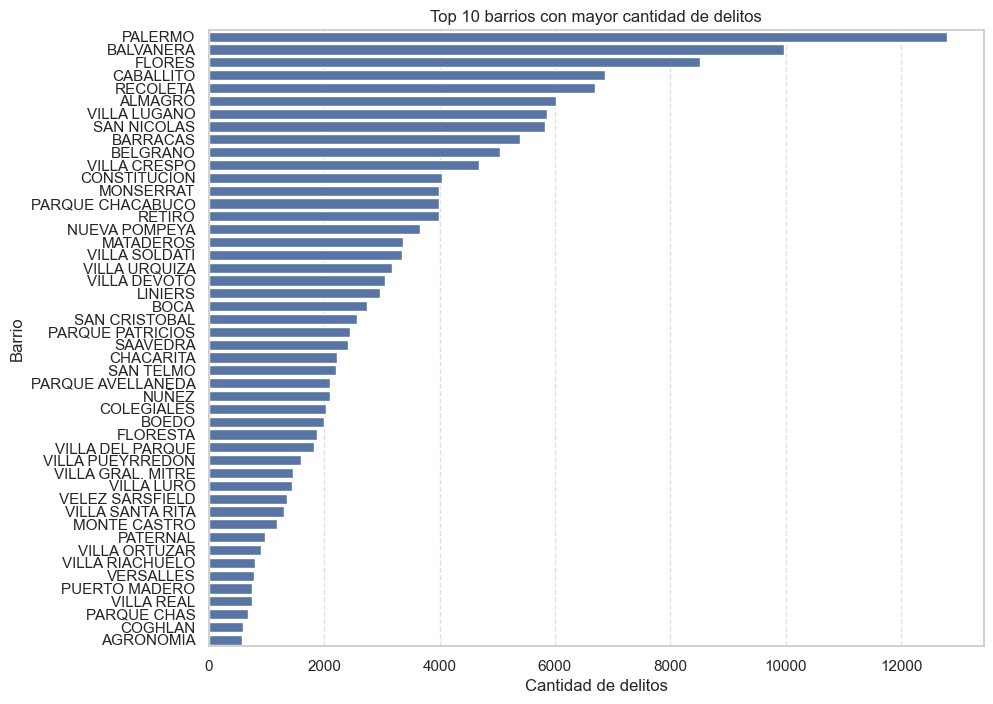

In [55]:
# Top 10 barrios con más delitos
delitos_barrio = (
    df.groupby('barrio', observed=True)['cantidad']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Si quiero mostrar sólo las 10 que seleccioné con 'head(10)', tengo que eliminar del dataframe las categorías que no tienen valores.
# esto lo hago con el método 'cat.remove_unused_categories()'
delitos_barrio['barrio'] = (delitos_barrio['barrio'].cat.remove_unused_categories())

print (delitos_barrio)
plt.figure(figsize=(10, 8))

sns.barplot(
    data=delitos_barrio,
    y='barrio',
    x='cantidad',
    order=delitos_barrio['barrio']
)

plt.title('Top 10 barrios con mayor cantidad de delitos')
plt.xlabel('Cantidad de delitos')
plt.ylabel('Barrio')
plt.grid(axis='x', alpha=0.6, linestyle='--') #supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

plt.show()

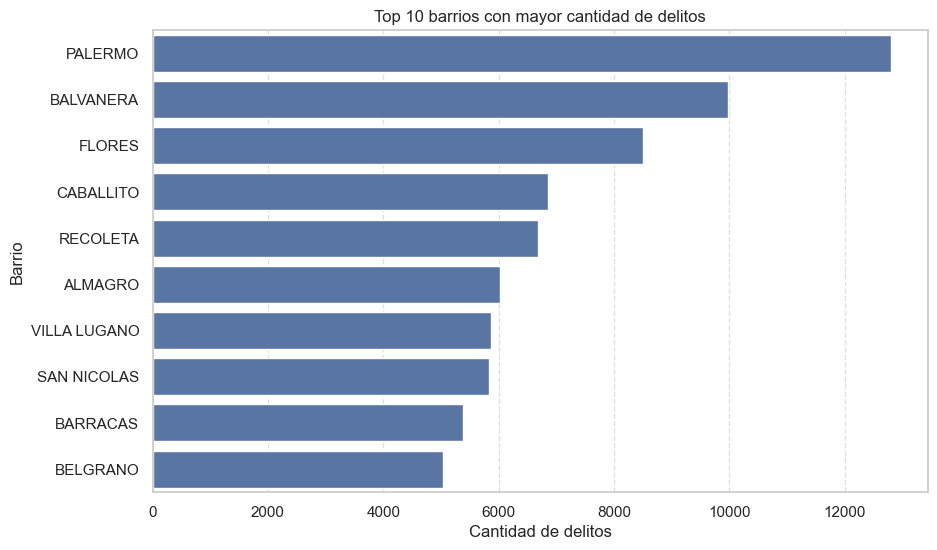

In [56]:
# Top 10 barrios con más delitos
delitos_barrio = (
    df.groupby('barrio', observed=True)['cantidad']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Si quiero mostrar sólo las 10 que seleccioné con 'head(10)', tengo que eliminar del dataframe las categorías que no tienen valores.
# esto lo hago con el método 'cat.remove_unused_categories()'
delitos_barrio['barrio'] = (delitos_barrio['barrio'].cat.remove_unused_categories())

plt.figure(figsize=(10, 6))

sns.barplot(
    data=delitos_barrio,
    y='barrio',
    x='cantidad',
    order=delitos_barrio['barrio']
)

plt.title('Top 10 barrios con mayor cantidad de delitos')
plt.xlabel('Cantidad de delitos')
plt.ylabel('Barrio')
plt.grid(axis='x', alpha=0.6, linestyle='--') #supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

plt.show()

### Análisis/conclusiones
- El barrio con mayor cantiad de delitos reportados en 2024 fue Palermo
- El momento del día de **menor ocurrencia** de delitos se da por la madrugada, **de 1 a 5**.
- El momento del día de **mayor ocurrencia** de delitos se da pasada las **5 de la mañana**.

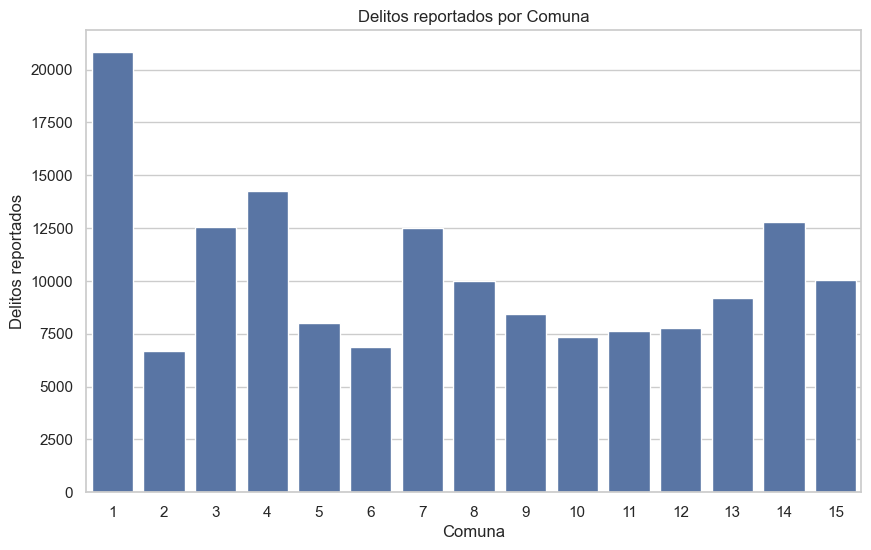

In [57]:
# Delitos por comuna
delitos_comuna = (
    df.groupby('comuna')['cantidad']
    .sum()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    y=delitos_comuna.values,
    x=delitos_comuna.index
)

plt.title('Delitos reportados por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Delitos reportados')

plt.show()

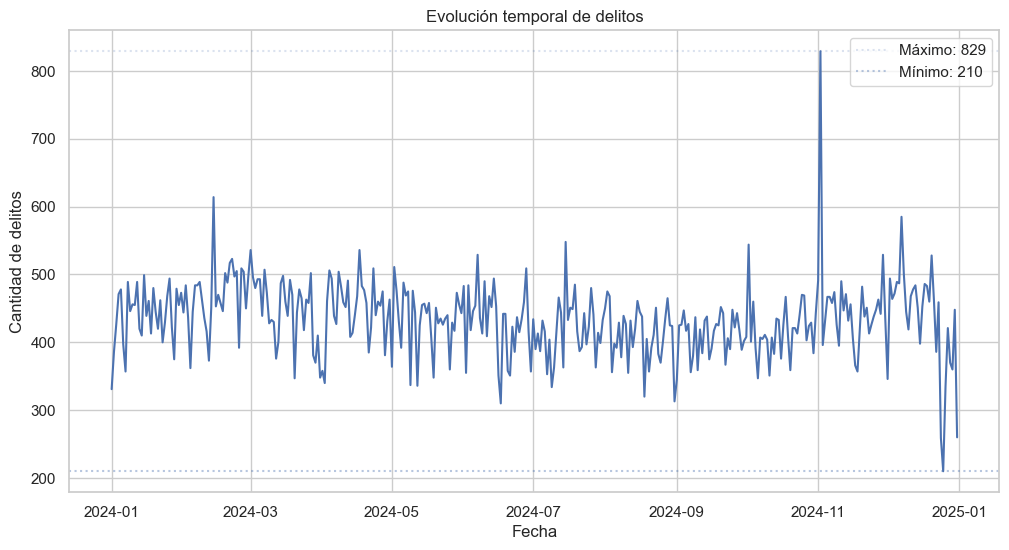

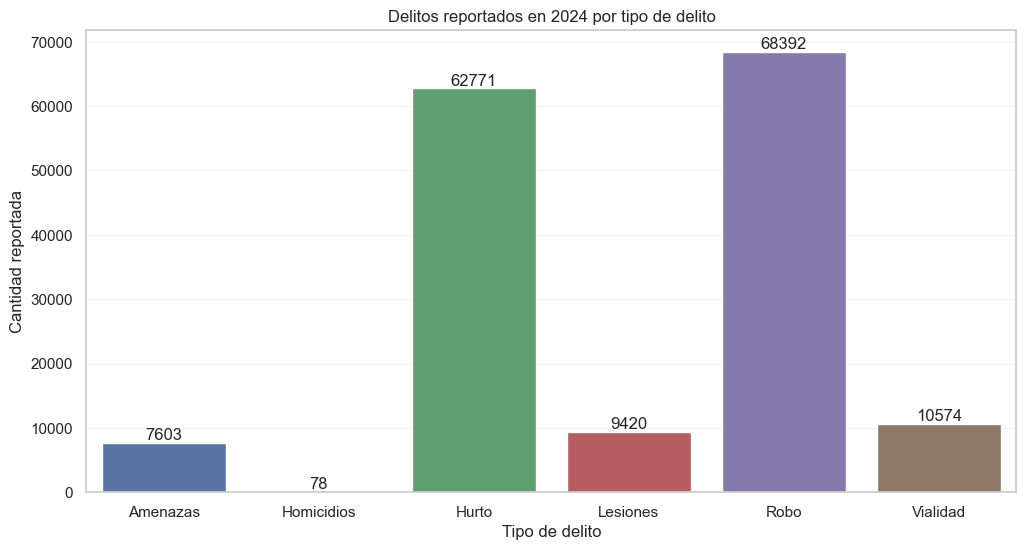

In [59]:
# Agrupar datos
delitos_tipo = (
    df.groupby('tipo', observed=True)['cantidad']
    .sum()
    .reset_index()
)

# Figura
plt.figure(figsize=(12, 6))

# Gráfico
ax = sns.barplot(
    data=delitos_tipo,
    x='tipo',
    y='cantidad',
    hue='tipo',
    dodge=False,
    legend=False
)

# Títulos y etiquetas
plt.title('Delitos reportados en 2024 por tipo de delito')
plt.xlabel('Tipo de delito')
plt.ylabel('Cantidad reportada')

# Grid
plt.grid(axis='y', alpha=0.2)

# Rotar etiquetas si hace falta
#plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

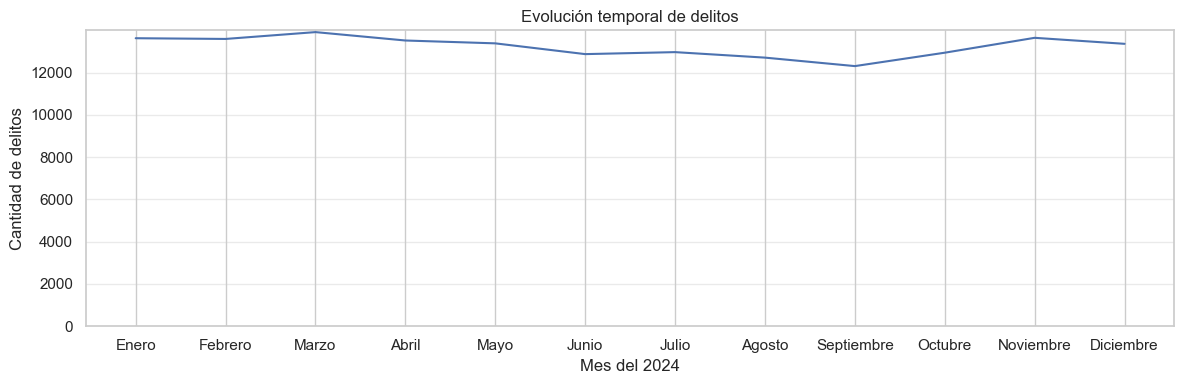

In [60]:
delitos_mes = (
    df.groupby('mes')['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 4))

sns.lineplot(
    data=delitos_mes,
    x='mes',
    y='cantidad'
)

plt.title('Evolución temporal de delitos')
plt.xlabel('Mes del 2024')
plt.ylabel('Cantidad de delitos')
plt.ylim(bottom=0)   # Inicia eje Y en 0
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

plt.show()

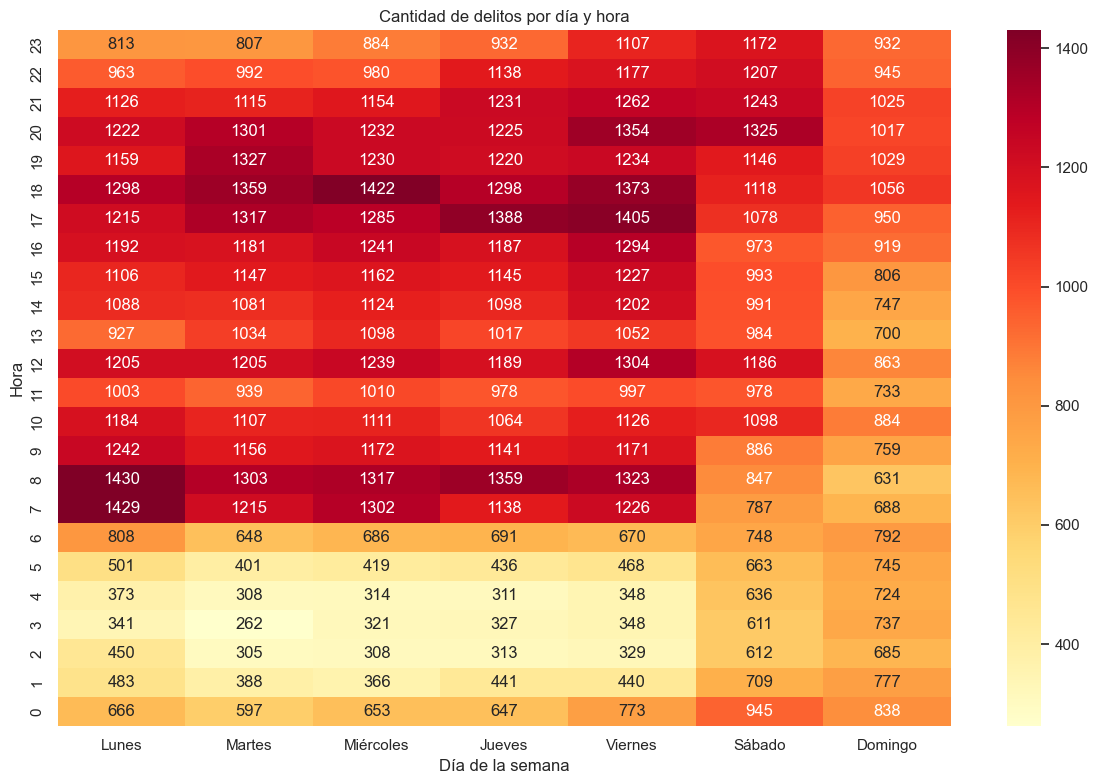

In [61]:
df_heatmap = pd.crosstab(
    df['franja'],
    df['dia']
)

# Gráfico
plt.figure(figsize=(12,8))

ax = sns.heatmap(
    df_heatmap,
    annot=True,      # muestra valores
    fmt='d',         # enteros
    cmap='YlOrRd'
)

ax.invert_yaxis() # hago esto para que las 0 aparezcan en la parte de abajo y las 23 arriba

plt.title('Cantidad de delitos por día y hora')
plt.xlabel('Día de la semana')
plt.ylabel('Hora')


plt.tight_layout()
plt.show()

El gráfico permite extraer varias conclusiones interesantes porque no solo muestra frecuencia por hora ni por día de forma aislada, sino la interacción entre ambas variables.

El análisis entre día de la semana y horario muestra patrones temporales diferenciados. Se observan mayores concentraciones de delitos durante franjas de alta movilidad urbana (mañana y tarde-noche), con un incremento particularmente marcado hacia el viernes. 

El comportamiento del día domingo presenta una dinámica distinta respecto de los días laborales.

In [62]:
df.sample(5)

,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
49635,2024,Mayo,Sábado,2024-05-11,22,Hurto,Hurto total,False,False,PALERMO,14,-34.578509,-58.419488,1
27665,2024,Marzo,Miércoles,2024-03-13,8,Hurto,Hurto total,False,False,SAN NICOLAS,1,-34.601586,-58.385146,1
107056,2024,Octubre,Viernes,2024-10-25,7,Hurto,Hurto total,False,False,RECOLETA,2,-34.597249,-58.393595,1
81855,2024,Agosto,Sábado,2024-08-10,11,Hurto,Hurto total,False,False,COLEGIALES,13,-34.577333,-58.447011,1
63159,2024,Junio,Martes,2024-06-18,9,Robo,Robo total,False,True,RECOLETA,2,-34.597001,-58.406512,1


In [63]:
df[df['dia'] == 'Lunes'].sample(5)

,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
138889,2024,Noviembre,Lunes,2024-11-04,16,Lesiones,Lesiones Dolosas,False,False,PARQUE AVELLANEDA,9,-34.640630,-58.480861,1
120831,2024,Diciembre,Lunes,2024-12-02,14,Robo,Robo total,False,False,BALVANERA,3,-34.615990,-58.409582,1
147920,2024,Diciembre,Lunes,2024-12-23,3,Amenazas,Amenazas,False,False,NaN,<NA>,NaN,NaN,1
131750,2024,Enero,Lunes,2024-01-22,18,Lesiones,Lesiones Dolosas,False,False,BALVANERA,3,-34.616629,-58.401411,1
110958,2024,Noviembre,Lunes,2024-11-04,12,Hurto,Hurto automotor,False,False,COLEGIALES,13,-34.578890,-58.452520,1


In [64]:
# Voy a tener que hacer algo con los datos para tener una variable con valores distintos para ver su comportamiento

In [65]:
# agrupo los datos por fecha

In [66]:
dfb = (
    df.groupby(['fecha'], observed=True)
      .size()
      .reset_index(name='cantidad')
)
#dfb[dfb['dia'] == 'Lunes']
dfb

,fecha,cantidad
0,2024-01-01,331
1,2024-01-02,386
2,2024-01-03,427
3,2024-01-04,471
4,2024-01-05,478
...,...,...
361,2024-12-27,421
362,2024-12-28,370
363,2024-12-29,360
364,2024-12-30,448


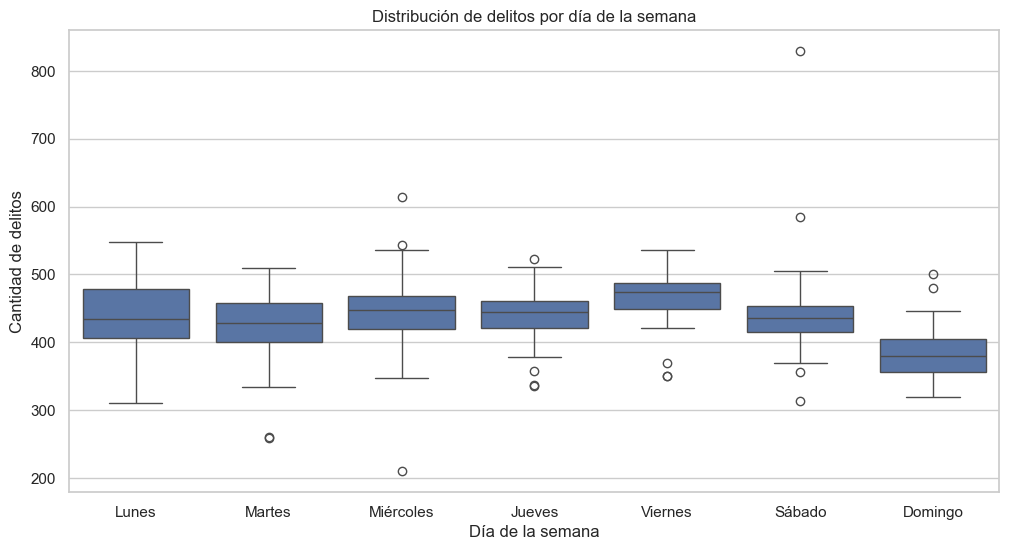

In [67]:
# Agrupar delitos por fecha y día
df_boxplot = (
    df.groupby(['fecha', 'dia'], observed=True)
      .size()
      .reset_index(name='cantidad_delitos')
)

# Crear gráfico
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_boxplot,
    x='dia',
    y='cantidad_delitos',
    #hue='dia'
    #order=orden_dias
)

plt.title('Distribución de delitos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de delitos')

plt.show()

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   anio      158838 non-null  int64         
 1   mes       158838 non-null  category      
 2   dia       158838 non-null  category      
 3   fecha     158838 non-null  datetime64[us]
 4   franja    158791 non-null  Int64         
 5   tipo      158838 non-null  category      
 6   subtipo   158838 non-null  category      
 7   uso_arma  158838 non-null  bool          
 8   uso_moto  158838 non-null  bool          
 9   barrio    154916 non-null  category      
 10  comuna    154916 non-null  Int64         
 11  latitud   155004 non-null  float64       
 12  longitud  155004 non-null  float64       
 13  cantidad  158838 non-null  int64         
dtypes: Int64(2), bool(2), category(5), datetime64[us](1), float64(2), int64(2)
memory usage: 9.8 MB
